<a href="https://colab.research.google.com/github/Aravindr017/SKINOVA/blob/model-evaluation-exporting/Model/Skinova_AI_skin_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES


#### 1. Environment Setup & Package Installation
Install required dependencies for data processing, image manipulation, and deep learning framework operations.

In [ ]:
%pip install -q pandas numpy opencv-python pillow matplotlib seaborn scikit-learn tqdm


Note: you may need to restart the kernel to use updated packages.


#### 2. Import Libraries & Configure Environment
Import necessary Python packages for data manipulation, computer vision, data visualization, and model development.

In [ ]:
import os

print(os.listdir("/kaggle/input"))


['datasets']


In [ ]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/GroundTruth.csv
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classif

In [ ]:
for dirname, dirs, files in os.walk("/kaggle/input"):
    print("\nFolder:", dirname)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])



Folder: /kaggle/input
Subfolders: ['datasets']
Files: []

Folder: /kaggle/input/datasets
Subfolders: ['surajghuwalewala']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala
Subfolders: ['ham1000-segmentation-and-classification']
Files: []

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'I

In [ ]:
from pathlib import Path
import pandas as pd
# Define paths based on Kaggle input directory
DATA_ROOT = Path(
    "/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification"
)

print("Dataset exists:", DATA_ROOT.exists())
print("Dataset path:", DATA_ROOT)


Dataset exists: True
Dataset path: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification


## Exploratory Data Analysis (EDA)
Load the ground truth labels and inspect the class distribution, missing values, and dataset size.

In [ ]:
# Load dataset metadata
metadata_path = DATA_ROOT / "GroundTruth.csv"

df = pd.read_csv(metadata_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# print("\nFirst 5 rows:")
# display(df.head())


Shape: (10015, 8)

Columns:
['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  object 
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), object(1)
memory usage: 626.1+ KB
None


In [ ]:
print(df.head(10))


          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
5  ISIC_0024311  0.0  1.0  0.0    0.0  0.0  0.0   0.0
6  ISIC_0024312  0.0  0.0  0.0    0.0  1.0  0.0   0.0
7  ISIC_0024313  1.0  0.0  0.0    0.0  0.0  0.0   0.0
8  ISIC_0024314  0.0  1.0  0.0    0.0  0.0  0.0   0.0
9  ISIC_0024315  1.0  0.0  0.0    0.0  0.0  0.0   0.0


In [ ]:
for root, dirs, files in os.walk(DATA_ROOT):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:10])


Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification
Subfolders: ['images', 'masks']
Files: ['GroundTruth.csv']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images
Subfolders: []
Files: ['ISIC_0030912.jpg', 'ISIC_0028933.jpg', 'ISIC_0030585.jpg', 'ISIC_0028394.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']

Folder: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/masks
Subfolders: []
Files: ['ISIC_0033034_segmentation.png', 'ISIC_0026058_segmentation.png', 'ISIC_0031698_segmentation.png', 'ISIC_0032330_segmentation.png', 'ISIC_0030246_segmentation.png', 'ISIC_0026281_segmentation.png', 'ISIC_0024577_segmentation.png', 'ISIC_0024910_segmentation.png', 'ISIC_0031771_segmentation.png', 'ISIC_0029679_segmentation.png']


In [ ]:
label_columns = df.columns[1:].tolist()


print("Label columns:", label_columns)

Label columns: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [ ]:
# Check each class
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

for col in classes:
    print(f"{col}: {df[col].sum()}")


MEL: 1113.0
NV: 6705.0
BCC: 514.0
AKIEC: 327.0
BKL: 1099.0
DF: 115.0
VASC: 142.0


In [ ]:
# ============================================================
# LABEL PREPROCESSING
# ============================================================

# HAM10000 classes present in GroundTruth.csv
classes = [
    "MEL",
    "NV",
    "BCC",
    "AKIEC",
    "BKL",
    "DF",
    "VASC"
]

# Check that all expected label columns exist
missing_classes = [c for c in classes if c not in df.columns]

if missing_classes:
    raise ValueError(
        f"Missing label columns in GroundTruth.csv: {missing_classes}"
    )

# Make sure label columns are numeric
df[classes] = df[classes].apply(
    pd.to_numeric,
    errors="coerce"
)

# Check for invalid/missing label values
print("Missing values in label columns:")
print(df[classes].isna().sum())

# Fill missing label values with 0
df[classes] = df[classes].fillna(0)

# Check that every image has exactly one class
df["label_sum"] = df[classes].sum(axis=1)

print("\nLabel sum distribution:")
print(df["label_sum"].value_counts())

# Keep only rows having exactly one positive class
df = df[df["label_sum"] == 1].copy()

# Convert one-hot encoded labels into class name
df["label"] = df[classes].idxmax(axis=1)

# Convert class name to numerical ID
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# assign numerical labels
df["label_id"] = label_encoder.fit_transform(df["label"])

#  create mappings
label_map = {
    label: int(label_id)
    for label, label_id in zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
}

# Reverse mapping – useful later during prediction
id_to_label = {
    v: k for k, v in label_map.items()
}

print("\nClass mapping:")
for class_name, class_id in label_map.items():
    print(f"{class_id} -> {class_name}")

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nFirst 10 records:")
display(
    df[["image", "label", "label_id"]].head(10)
)

Missing values in label columns:
MEL      0
NV       0
BCC      0
AKIEC    0
BKL      0
DF       0
VASC     0
dtype: int64

Label sum distribution:
label_sum
1.0    10015
Name: count, dtype: int64

Class mapping:
0 -> AKIEC
1 -> BCC
2 -> BKL
3 -> DF
4 -> MEL
5 -> NV
6 -> VASC

Class distribution:
label
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64

First 10 records:


,image,label,label_id
0,ISIC_0024306,NV,5
1,ISIC_0024307,NV,5
2,ISIC_0024308,NV,5
3,ISIC_0024309,NV,5
4,ISIC_0024310,MEL,4
5,ISIC_0024311,NV,5
6,ISIC_0024312,BKL,2
7,ISIC_0024313,MEL,4
8,ISIC_0024314,NV,5
9,ISIC_0024315,MEL,4


In [ ]:
#Check the image files
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png"}

image_files = []

for path in DATA_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in image_extensions:
        image_files.append(path)

print("Total image files found:", len(image_files))

print("\nFirst 20 images:")
for path in image_files[:20]:
    print(path)


Total image files found: 20030

First 20 images:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028100.jpg
/kaggle/input/d

In [ ]:
mask_files = []

for path in DATA_ROOT.rglob("*"):
    if path.is_file() and path.suffix.lower() in image_extensions:
        if "mask" in str(path).lower() or "segment" in str(path).lower():
            mask_files.append(path)

print("Possible mask files:", len(mask_files))

for path in mask_files[:20]:
    print(path)


Possible mask files: 20030
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0027799.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028100.jpg
/kaggle/input/datasets/surajghuwalewa

In [ ]:
#Check the image names against the CSV
print("CSV image examples:")
print(df["image"].head(10).tolist())


CSV image examples:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']


In [ ]:
print("\nActual image examples:")

for path in image_files[:10]:
    print(path.name)



Actual image examples:
ISIC_0030912.jpg
ISIC_0028933.jpg
ISIC_0030585.jpg
ISIC_0028394.jpg
ISIC_0033697.jpg
ISIC_0030062.jpg
ISIC_0031213.jpg
ISIC_0027799.jpg
ISIC_0028100.jpg
ISIC_0027960.jpg


In [ ]:
image_path_dict = {
    path.stem: str(path)
    for path in image_files
}

df["image_path"] = df["image"].map(image_path_dict)

print(df[["image", "image_path"]].head(10))


          image                                         image_path
0  ISIC_0024306  /kaggle/input/datasets/surajghuwalewala/ham100...
1  ISIC_0024307  /kaggle/input/datasets/surajghuwalewala/ham100...
2  ISIC_0024308  /kaggle/input/datasets/surajghuwalewala/ham100...
3  ISIC_0024309  /kaggle/input/datasets/surajghuwalewala/ham100...
4  ISIC_0024310  /kaggle/input/datasets/surajghuwalewala/ham100...
5  ISIC_0024311  /kaggle/input/datasets/surajghuwalewala/ham100...
6  ISIC_0024312  /kaggle/input/datasets/surajghuwalewala/ham100...
7  ISIC_0024313  /kaggle/input/datasets/surajghuwalewala/ham100...
8  ISIC_0024314  /kaggle/input/datasets/surajghuwalewala/ham100...
9  ISIC_0024315  /kaggle/input/datasets/surajghuwalewala/ham100...


In [ ]:
print(
    "Images found:",
    df["image_path"].notna().sum()
)

print(
    "Images missing:",
    df["image_path"].isna().sum()
)


Images found: 10015
Images missing: 0


In [ ]:
#Remove invalid records
df = df.dropna(
    subset=["image_path"]
).copy()

print("Remaining images:", len(df))


Remaining images: 10015


In [ ]:
#Check for corrupted images
from PIL import Image
from tqdm import tqdm

bad_images = []

for path in tqdm(
    df["image_path"],
    desc="Checking images"
):
    try:
        with Image.open(path) as img:
            img.verify()

    except Exception:
        bad_images.append(path)

print("Corrupted images:", len(bad_images))


Checking images: 100%|██████████| 10015/10015 [00:09<00:00, 1024.15it/s]

Corrupted images: 0


In [ ]:
#Check image dimensions
from collections import Counter

sizes = []

for path in tqdm(
    df["image_path"],
    desc="Checking dimensions"
):

    with Image.open(path) as img:
        sizes.append(img.size)

print("Most common image sizes:")

for size, count in Counter(sizes).most_common(10):
    print(size, ":", count)


Checking dimensions: 100%|██████████| 10015/10015 [00:10<00:00, 997.97it/s]

Most common image sizes:
(600, 450) : 10015


# Image Visualization
Display sample images from the dataset along with their corresponding ground truth annotations.

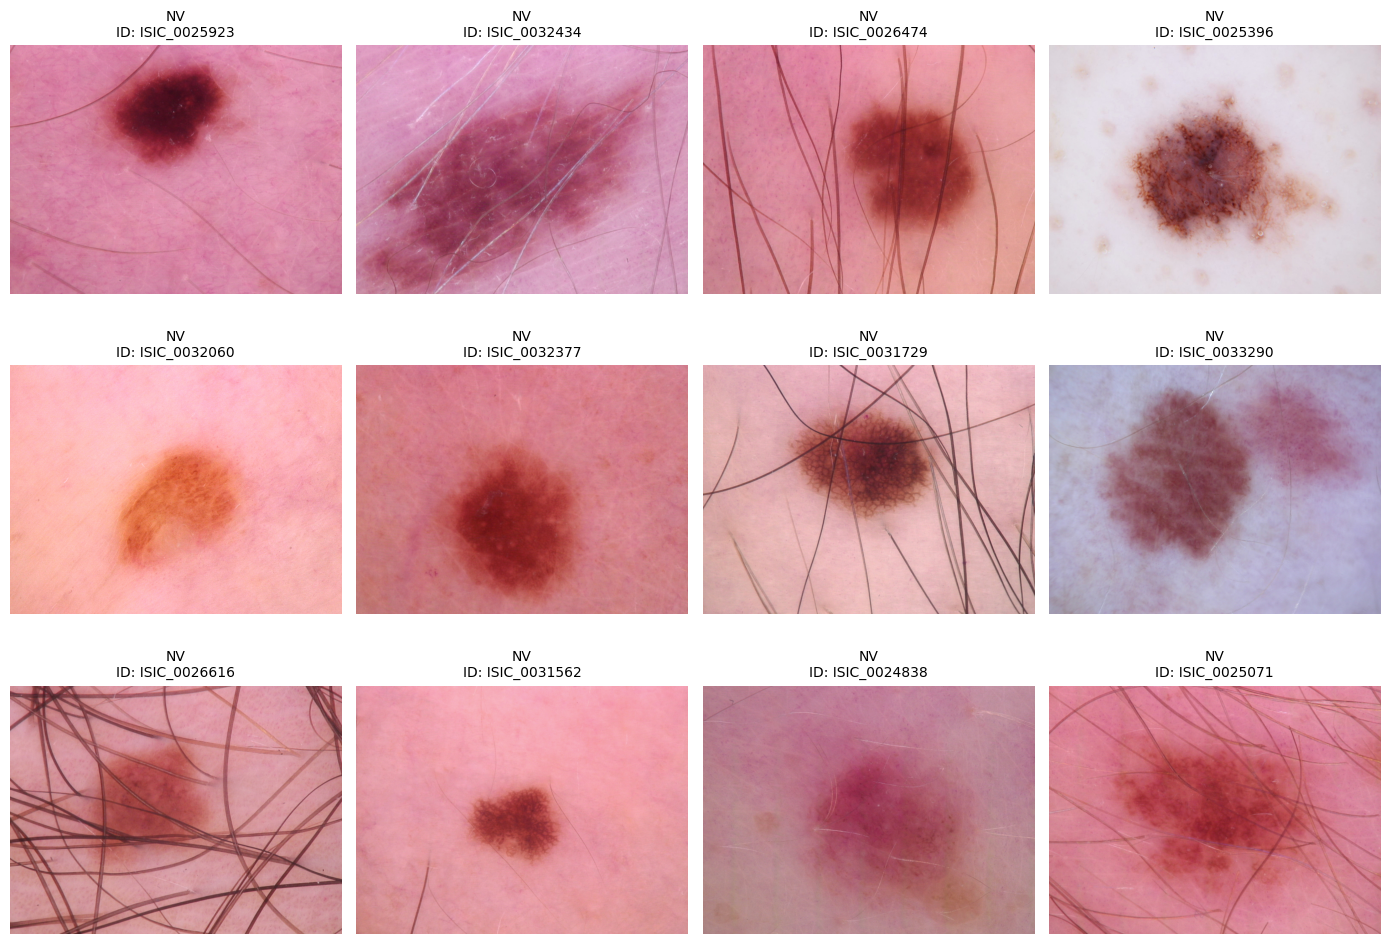

In [ ]:
#Visualize some images
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(
    12,
    random_state=42
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10)
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_df.iterrows()
):

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"{row['label']}\nID: {row['image']}",
        fontsize=10
    )

    ax.axis("off")

plt.tight_layout()
plt.show()


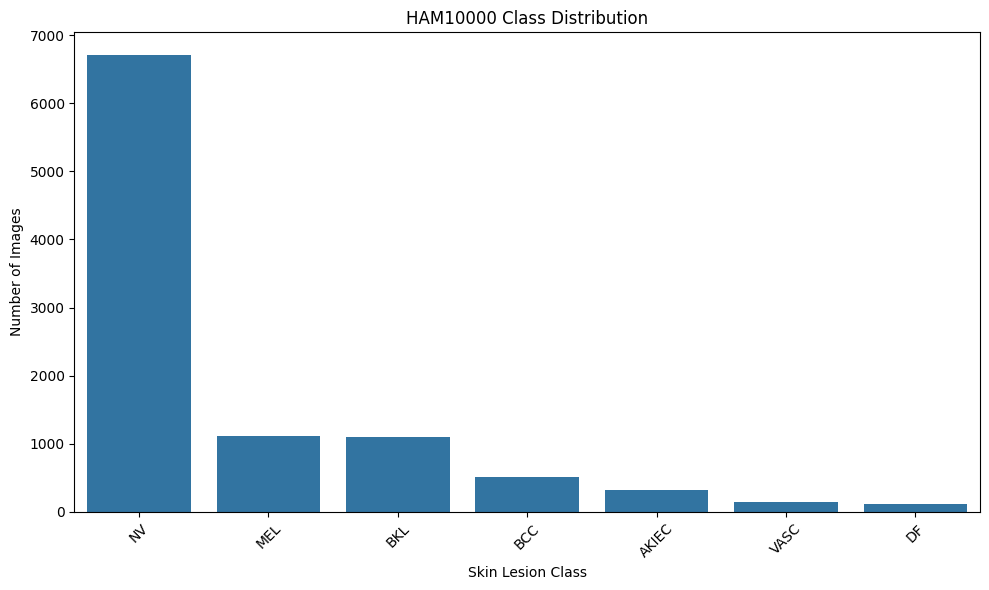

In [ ]:
#Check class distribution visually
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.title(
    "HAM10000 Class Distribution"
)

plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
#display percentages
class_distribution = df["label"].value_counts()

class_percentage = (
    df["label"].value_counts(normalize=True) * 100
).round(2)

distribution_table = pd.DataFrame({
    "Count": class_distribution,
    "Percentage": class_percentage
})

display(distribution_table)

,Count,Percentage
label,,
NV,6705,66.95
MEL,1113,11.11
BKL,1099,10.97
BCC,514,5.13
AKIEC,327,3.27
VASC,142,1.42
DF,115,1.15


In [ ]:
#Save our cleaned metadata
from pathlib import Path

PROCESSED_DIR = Path("/kaggle/working/skinova_processed")

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [ ]:
df.to_csv(
    PROCESSED_DIR / "cleaned_metadata.csv",
    index=False
)

print(
    "Saved to:",
    PROCESSED_DIR / "cleaned_metadata.csv"
)


Saved to: /kaggle/working/skinova_processed/cleaned_metadata.csv


In [ ]:
print("Number of CSV rows:", len(df))

print("\nCSV image names:")
print(df["image"].head(10).tolist())

print("\nNumber of image files found:", len(image_files))

print("\nActual image files:")
for path in image_files[:20]:
    print(path)

print("\nNumber of mask files found:", len(mask_files))

print("\nActual mask files:")
for path in mask_files[:20]:
    print(path)


Number of CSV rows: 10015

CSV image names:
['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', 'ISIC_0024309', 'ISIC_0024310', 'ISIC_0024311', 'ISIC_0024312', 'ISIC_0024313', 'ISIC_0024314', 'ISIC_0024315']

Number of image files found: 20030

Actual image files:
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030912.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028933.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030585.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0030062.jpg
/kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
/kaggle/in

In [ ]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# First split:
# 80% training
# 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label_id"],
    random_state=42
)

# Second split:
# 10% validation
# 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_id"],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples  :", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples   :", len(test_df))

Training samples  : 8012
Validation samples: 1001
Testing samples   : 1002


In [ ]:
print("\nTraining distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())


Training distribution:
label
NV       5364
MEL       890
BKL       879
BCC       411
AKIEC     262
VASC      114
DF         92
Name: count, dtype: int64

Validation distribution:
label
NV       670
MEL      111
BKL      110
BCC       51
AKIEC     33
VASC      14
DF        12
Name: count, dtype: int64

Test distribution:
label
NV       671
MEL      112
BKL      110
BCC       52
AKIEC     32
VASC      14
DF        11
Name: count, dtype: int64


# Data Augmentation

In [ ]:
%pip install -q albumentations


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A
from pathlib import Path
from tqdm import tqdm

In [ ]:
# ============================================================
# AUGMENTATION PIPELINE
# ============================================================

augmentation_pipeline = A.Compose([

    # Geometric transformations
    A.HorizontalFlip(p=0.5),
    A.Rotate(
        limit=15,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=0,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.4
    ),

    # Mild color/intensity transformations
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),

    # Slight image quality variation
    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.15
    )
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# ============================================================
# CREATE AUGMENTED DATASET DIRECTORY
# ============================================================

AUGMENTED_DIR = Path("/kaggle/working/skinova_augmented")

TRAIN_AUG_DIR = AUGMENTED_DIR / "train"

TRAIN_AUG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Augmented dataset directory:")
print(TRAIN_AUG_DIR)

Augmented dataset directory:
/kaggle/working/skinova_augmented/train


In [ ]:
# ============================================================
# TRAINING CLASS DISTRIBUTION BEFORE AUGMENTATION
# ============================================================

train_distribution = train_df["label"].value_counts().sort_index()

print("Training distribution BEFORE augmentation:")
print(train_distribution)

Training distribution BEFORE augmentation:
label
AKIEC     262
BCC       411
BKL       879
DF         92
MEL       890
NV       5364
VASC      114
Name: count, dtype: int64


In [ ]:
# ============================================================
# AUGMENTATION TARGET
# ============================================================

TARGET_IMAGES_PER_CLASS = 2000

print(
    "Target images per minority class:",
    TARGET_IMAGES_PER_CLASS
)

Target images per minority class: 2000


In [ ]:
# ============================================================
# GENERATE AUGMENTED TRAINING IMAGES
# ============================================================

augmented_records = []

# Keep track of the original training images
for _, row in train_df.iterrows():

    augmented_records.append({
        "image": row["image"],
        "image_path": row["image_path"],
        "label": row["label"],
        "label_id": row["label_id"],
        "is_augmented": 0
    })


# Process each class separately
for class_name in train_df["label"].unique():

    class_df = train_df[
        train_df["label"] == class_name
    ].copy()

    current_count = len(class_df)

    # Number of additional images required
    images_to_generate = max(
        0,
        TARGET_IMAGES_PER_CLASS - current_count
    )

    print(
        f"\nClass: {class_name}"
    )
    print(
        f"Original images: {current_count}"
    )
    print(
        f"Augmented images required: {images_to_generate}"
    )

    if images_to_generate == 0:
        continue

    # Generate augmented images
    for i in tqdm(
        range(images_to_generate),
        desc=f"Augmenting {class_name}"
    ):

        # Randomly select an original image from this class
        row = class_df.sample(
            n=1,
            random_state=42 + i
        ).iloc[0]

        image_path = row["image_path"]

        # Read image
        image = cv2.imread(image_path)

        if image is None:
            print(
                f"Warning: Could not read {image_path}"
            )
            continue

        # Convert BGR -> RGB
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # Apply augmentation
        augmented = augmentation_pipeline(
            image=image
        )

        augmented_image = augmented["image"]

        # Convert RGB -> BGR for saving
        augmented_image = cv2.cvtColor(
            augmented_image,
            cv2.COLOR_RGB2BGR
        )

        # Create unique filename
        original_name = Path(
            row["image_path"]
        ).stem

        new_filename = (
            f"{original_name}_aug_{i:05d}.jpg"
        )

        output_path = (
            TRAIN_AUG_DIR /
            new_filename
        )

        # Save augmented image
        cv2.imwrite(
            str(output_path),
            augmented_image,
            [cv2.IMWRITE_JPEG_QUALITY, 95]
        )

        # Store metadata
        augmented_records.append({
            "image": new_filename,
            "image_path": str(output_path),
            "label": row["label"],
            "label_id": row["label_id"],
            "is_augmented": 1
        })

print("\nData augmentation completed.")


Class: NV
Original images: 5364
Augmented images required: 0

Class: AKIEC
Original images: 262
Augmented images required: 1738


Augmenting AKIEC: 100%|██████████| 1738/1738 [00:20<00:00, 82.98it/s]



Class: BKL
Original images: 879
Augmented images required: 1121


Augmenting BKL: 100%|██████████| 1121/1121 [00:13<00:00, 81.95it/s]



Class: BCC
Original images: 411
Augmented images required: 1589


...


Class: VASC
Original images: 114
Augmented images required: 1886


Augmenting VASC: 100%|██████████| 1886/1886 [00:23<00:00, 80.23it/s]



Class: DF
Original images: 92
Augmented images required: 1908


Augmenting DF: 100%|██████████| 1908/1908 [00:23<00:00, 79.71it/s]


Data augmentation completed.


In [ ]:
# ============================================================
# CREATE AUGMENTED TRAINING METADATA
# ============================================================

augmented_train_df = pd.DataFrame(
    augmented_records
)

print(
    "Total training images after augmentation:",
    len(augmented_train_df)
)

print("\nClass distribution AFTER augmentation:")
print(
    augmented_train_df["label"].value_counts()
)

Total training images after augmentation: 17364

Class distribution AFTER augmentation:
label
NV       5364
AKIEC    2000
BKL      2000
BCC      2000
MEL      2000
VASC     2000
DF       2000
Name: count, dtype: int64


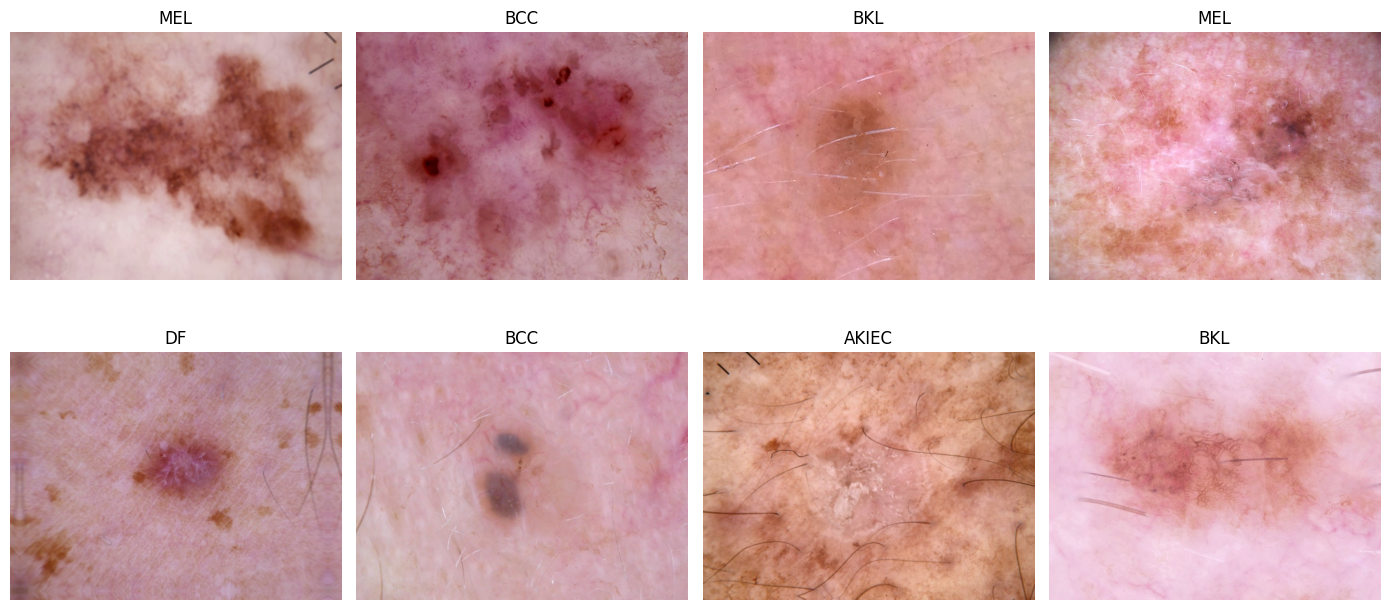

In [ ]:
# ============================================================
# VISUALIZE AUGMENTED IMAGES
# ============================================================

import matplotlib.pyplot as plt

# Select augmented images only
sample_aug = augmented_train_df[
    augmented_train_df["is_augmented"] == 1
].sample(
    8,
    random_state=42
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7)
)

for ax, (_, row) in zip(
    axes.flatten(),
    sample_aug.iterrows()
):

    image = cv2.imread(
        row["image_path"]
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image)

    ax.set_title(
        row["label"]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

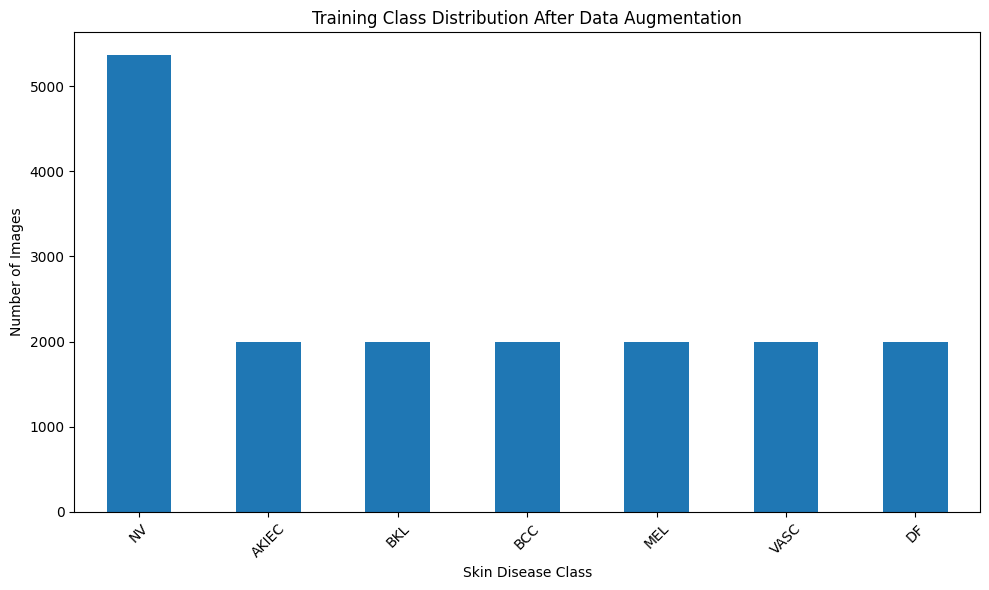

In [ ]:
# ============================================================
# CLASS DISTRIBUTION AFTER AUGMENTATION
# ============================================================

plt.figure(figsize=(10, 6))

augmented_train_df["label"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Training Class Distribution After Data Augmentation"
)

plt.xlabel("Skin Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE AUGMENTED METADATA
# ============================================================

augmented_metadata_path = (
    AUGMENTED_DIR /
    "augmented_train_metadata.csv"
)

augmented_train_df.to_csv(
    augmented_metadata_path,
    index=False
)

print(
    "Augmented metadata saved to:"
)

print(
    augmented_metadata_path
)

Augmented metadata saved to:
/kaggle/working/skinova_augmented/augmented_train_metadata.csv


In [ ]:
# ============================================================
# SAVE VALIDATION AND TEST METADATA
# ============================================================

val_df.to_csv(
    AUGMENTED_DIR / "validation_metadata.csv",
    index=False
)

test_df.to_csv(
    AUGMENTED_DIR / "test_metadata.csv",
    index=False
)

print("Validation metadata saved.")
print("Test metadata saved.")

Validation metadata saved.
Test metadata saved.


# CNN Model Development

## Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Numerical and dataframe libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


from tensorflow.keras.preprocessing.image import ImageDataGenerator


TensorFlow version: 2.20.0


## Model Configuration

In [ ]:
# Number of skin disease classes
NUM_CLASSES = 7

# Image size used for model training
IMG_SIZE = 240

# Number of images processed at one time
BATCH_SIZE = 32

# Random seed for reproducibility
SEED = 42

# Skin disease class names
CLASSES = [
    "AKIEC",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "VASC"
]

print("Number of classes:", NUM_CLASSES)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASSES)

Number of classes: 7
Image size: 240
Batch size: 32
Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


## Create Training, Validation and Test Generators

In [ ]:

# No additional augmentation here.
# Augmentation was already performed in the previous notebook.

train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()



# TRAINING GENERATOR

train_generator = train_datagen.flow_from_dataframe(
    dataframe=augmented_train_df,
    x_col="image_path",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,

    class_mode="categorical",
    shuffle=True,

    seed=SEED
)


# VALIDATION GENERATOR

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,

    class_mode="categorical",
    shuffle=False
)


# TEST GENERATOR

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,

    class_mode="categorical",
    shuffle=False
)


print("\nClass indices:")
print(train_generator.class_indices)

Found 17364 validated image filenames belonging to 7 classes.
Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.

Class indices:
{'AKIEC': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'VASC': 6}


In [ ]:
# CHECK TRAINING DATA

images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Image batch shape: (32, 240, 240, 3)
Label batch shape: (32, 7)
Minimum pixel value: 0.0
Maximum pixel value: 255.0


## Visualize Training Images

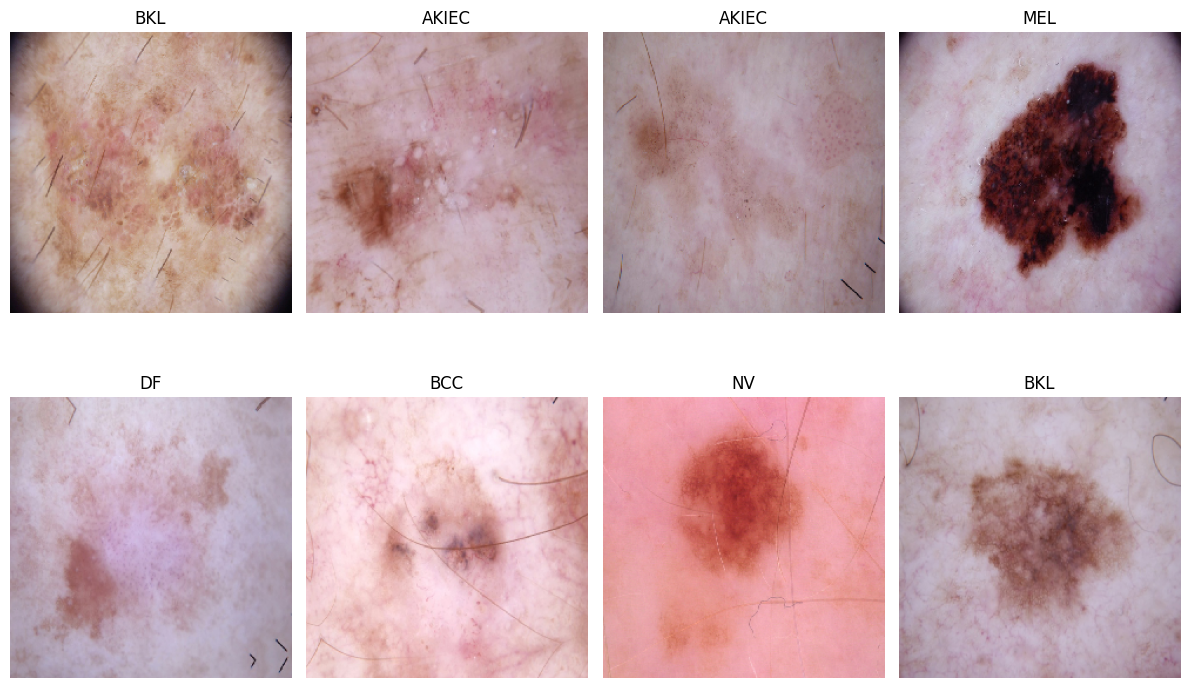

In [ ]:
# VISUALIZE TRAINING BATCH

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i].astype("uint8"))

    # Convert one-hot encoded label into class ID
    class_id = np.argmax(labels[i])

    # Get class name
    class_name = CLASSES[class_id]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Create Training Callbacks

In [ ]:
# TRAINING CALLBACKS

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


# Stop training if validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# Reduce learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

## MODEL 1  EfficientNetB0

In [ ]:
# BUILDING EFFICIENTNETB0
#

from tensorflow.keras.applications import EfficientNetB0

# Load EfficientNetB0 without the original classification layer
base_b0 = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained layers initially
base_b0.trainable = False


# CREATE EFFICIENTNETB0 CLASSIFICATION MODEL
#

efficientnet_b0 = keras.Sequential([

    # Input layer
    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Pretrained EfficientNetB0
    base_b0,

    # Convert feature maps into a feature vector
    layers.GlobalAveragePooling2D(),

    # Normalize extracted features
    layers.BatchNormalization(),

    # Fully connected layer
    layers.Dense(
        256,
        activation="relu"
    ),

    # Reduce overfitting
    layers.Dropout(0.4),

    # Final 7-class classification layer
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


# DISPLAY MODEL ARCHITECTURE

efficientnet_b0.summary()

I0000 00:00:1789363862.548987      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789363862.552240      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Compile EfficientNetB0

In [ ]:
efficientnet_b0.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully.")

EfficientNetB0 compiled successfully.


## Train EfficientNetB0

In [ ]:
checkpoint_b0 = ModelCheckpoint(
    "/kaggle/working/skinova_efficientnetb0_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)


history_b0 = efficientnet_b0.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b0
    ]
)

Epoch 1/15


2026-09-14 05:31:24.462025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:31:24.606014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:31:24.951872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:31:25.092705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:31:25.882215: E external/local_xla/xla/stream_

356/543 ━━━━━━━━━━━━━━━━━━━━ 27s 146ms/step - accuracy: 0.3871 - loss: 1.8282

2026-09-14 05:32:32.534789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:32:32.675574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:32:33.005819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:32:33.146434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:32:33.961443: E external/local_xla/xla/stream_

543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4249 - loss: 1.6971

2026-09-14 05:33:26.034541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:33:26.169928: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:33:26.486058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:33:26.633776: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 05:33:26.773377: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.71229, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 1: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 146s 219ms/step - accuracy: 0.5160 - loss: 1.3865 - val_accuracy: 0.7123 - val_loss: 0.8101 - learning_rate: 1.0000e-04
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6438 - loss: 0.9786
Epoch 2: val_accuracy improved from 0.71229 to 0.74426, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 86s 158ms/step - accuracy: 0.6595 - loss: 0.9382 - val_accuracy: 0.7443 - val_loss: 0.6983 - learning_rate: 1.0000e-04
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7079 - loss: 0.8047
Epoch 3: val_accuracy improved from 0.74426 to 0.75025, saving model to /kaggle/working/skinova_efficientnetb0_best

## Plot EfficientNetB0 Training Results

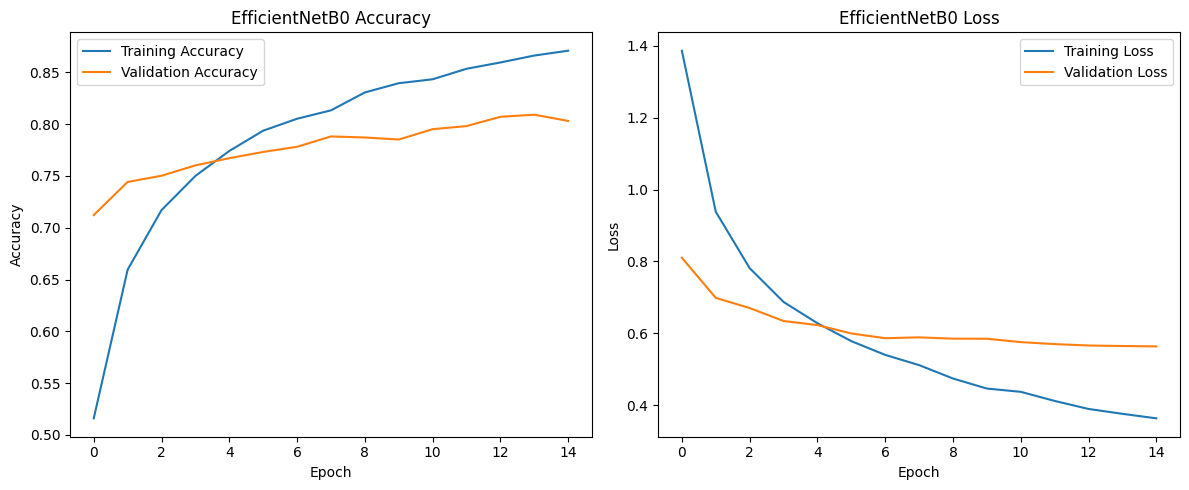

In [ ]:
plt.figure(figsize=(12, 5))

# Training and validation accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_b0.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_b0.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Training and validation loss
plt.subplot(1, 2, 2)

plt.plot(
    history_b0.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_b0.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Fine-Tune EfficientNetB0

In [ ]:
# Unfreeze the EfficientNetB0 base model
base_b0.trainable = True


# Freeze earlier layers
# Only the last 30 layers will be trainable
for layer in base_b0.layers[:-30]:

    layer.trainable = False


# Keep BatchNormalization layers frozen
# This helps maintain stable pretrained statistics
for layer in base_b0.layers:

    if isinstance(layer, layers.BatchNormalization):

        layer.trainable = False


# Recompile with a smaller learning rate
efficientnet_b0.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


print("EfficientNetB0 ready for fine-tuning.")

EfficientNetB0 ready for fine-tuning.


In [ ]:

history_b0_finetune = efficientnet_b0.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b0
    ]
)

Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8842 - loss: 0.3376
Epoch 1: val_accuracy did not improve from 0.80919
543/543 ━━━━━━━━━━━━━━━━━━━━ 136s 207ms/step - accuracy: 0.8831 - loss: 0.3337 - val_accuracy: 0.8092 - val_loss: 0.5541 - learning_rate: 1.0000e-05
Epoch 2/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8859 - loss: 0.3240
Epoch 2: val_accuracy improved from 0.80919 to 0.81718, saving model to /kaggle/working/skinova_efficientnetb0_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb0_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 89s 163ms/step - accuracy: 0.8876 - loss: 0.3207 - val_accuracy: 0.8172 - val_loss: 0.5484 - learning_rate: 1.0000e-05
Epoch 3/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8930 - loss: 0.3033
Epoch 3: val_accuracy did not improve from 0.81718
543/543 ━━━━━━━━━━━━━━━━━━━━ 85s 156ms/step - accuracy: 0.8934 - loss: 0.2998 - val_accuracy: 0.8112 - val_loss: 0.5404 - learning

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

# Reset test generator
test_generator.reset()

# Get predictions
predictions = efficientnet_b0.predict(
    test_generator,
    verbose=1
)

# Convert probabilities to predicted class IDs
y_pred = np.argmax(
    predictions,
    axis=1
)

# Actual class IDs
y_true = test_generator.classes

# Class names in correct order
class_names = list(
    test_generator.class_indices.keys()
)

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step

2026-09-14 06:08:55.878981: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:08:56.016184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:08:56.336916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:08:56.477401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:08:57.259647: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 602ms/step
Classification Report:

              precision    recall  f1-score   support

       AKIEC     0.6667    0.5625    0.6102        32
         BCC     0.7778    0.6731    0.7216        52
         BKL     0.6250    0.5909    0.6075       110
          DF     0.5000    0.4545    0.4762        11
         MEL     0.5000    0.4107    0.4510       112
          NV     0.8773    0.9270    0.9014       671
        VASC     0.7333    0.7857    0.7586        14

    accuracy                         0.8004      1002
   macro avg     0.6686    0.6292    0.6466      1002
weighted avg     0.7894    0.8004    0.7935      1002



<Figure size 900x800 with 0 Axes>

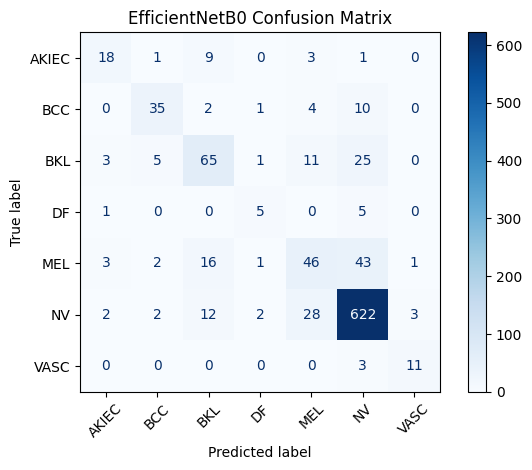

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "EfficientNetB0 Confusion Matrix"
)

plt.tight_layout()
plt.show()

## Save EfficientNetB0

In [ ]:
efficientnet_b0.save(
    "/kaggle/working/skinova_efficientnetb0_final.keras"
)

print("EfficientNetB0 saved successfully.")

EfficientNetB0 saved successfully.


## MODEL 2  EfficientNetB1

## Build EfficientNetB1

In [ ]:
from tensorflow.keras.applications import EfficientNetB1


# Load pretrained EfficientNetB1
base_b1 = EfficientNetB1(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


# Freeze base layers initially
base_b1.trainable = False


# Build classification model
efficientnet_b1 = keras.Sequential([

    # Input
    layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    # Pretrained EfficientNetB1
    base_b1,

    # Global feature extraction
    layers.GlobalAveragePooling2D(),

    # Feature normalization
    layers.BatchNormalization(),

    # Fully connected layer
    layers.Dense(
        256,
        activation="relu"
    ),

    # Dropout for regularization
    layers.Dropout(0.4),

    # Seven disease classes
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


efficientnet_b1.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 8, 8, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,910,094 (26.36 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

## Compile EfficentNetB1

In [ ]:
efficientnet_b1.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("EfficientNetB1 compiled successfully.")

EfficientNetB1 compiled successfully.


## Train EfficientNetB1

In [ ]:
checkpoint_b1 = ModelCheckpoint(

    "/kaggle/working/skinova_efficientnetb1_best.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)


history_b1 = efficientnet_b1.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b1
    ]
)

Epoch 1/15


2026-09-14 06:09:24.099500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:09:24.257844: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


137/543 ━━━━━━━━━━━━━━━━━━━━ 58s 144ms/step - accuracy: 0.2521 - loss: 2.3611

2026-09-14 06:10:00.130779: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:10:00.290112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.3978 - loss: 1.8173

2026-09-14 06:11:27.352708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:11:27.511456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.71928, saving model to /kaggle/working/skinova_efficientnetb1_best.keras

Epoch 1: finished saving model to /kaggle/working/skinova_efficientnetb1_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 149s 219ms/step - accuracy: 0.5025 - loss: 1.4424 - val_accuracy: 0.7193 - val_loss: 0.7634 - learning_rate: 1.0000e-04
Epoch 2/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6271 - loss: 1.0299
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 2: val_accuracy improved from 0.71928 to 0.74426, saving model to /kaggle/working/skinova_efficientnetb1_best.keras

Epoch 2: finished saving model to /kaggle/working/skinova_efficientnetb1_best.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 85s 156ms/step - accuracy: 0.6455 - loss: 0.9742 - val_accuracy: 0.7443 - val_loss: 0.6928 - learning_rate: 1.0000e-04
Epoch 3/15
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6916 - loss: 0.8503
Epoch 3: val_accuracy improved from 0.

## Plot EfficientNetB1 Training Results

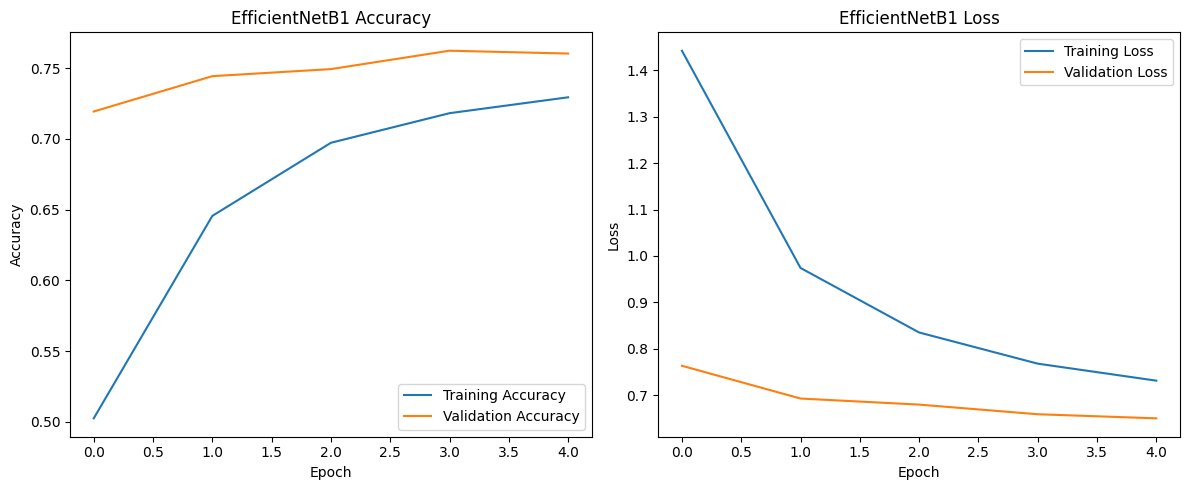

In [ ]:
plt.figure(figsize=(12, 5))


# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history_b1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_b1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history_b1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_b1.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.tight_layout()
plt.show()

## Fine-Tune EfficientNetB1

In [ ]:
# Unfreeze the base model
base_b1.trainable = True


# Freeze earlier layers
for layer in base_b1.layers[:-30]:

    layer.trainable = False


# Keep BatchNormalization layers frozen
for layer in base_b1.layers:

    if isinstance(layer, layers.BatchNormalization):

        layer.trainable = False


# Recompile using a smaller learning rate
efficientnet_b1.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


print("EfficientNetB1 ready for fine-tuning.")

EfficientNetB1 ready for fine-tuning.


In [ ]:

history_b1_finetune = efficientnet_b1.fit(

    train_generator,

    validation_data=val_generator,

    epochs=10,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_b1
    ]
)

Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6351 - loss: 1.0114
Epoch 1: val_accuracy did not improve from 0.76224
543/543 ━━━━━━━━━━━━━━━━━━━━ 153s 222ms/step - accuracy: 0.6441 - loss: 0.9870 - val_accuracy: 0.7353 - val_loss: 0.7288 - learning_rate: 1.0000e-05
Epoch 2/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6631 - loss: 0.9291
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy did not improve from 0.76224
543/543 ━━━━━━━━━━━━━━━━━━━━ 85s 156ms/step - accuracy: 0.6738 - loss: 0.8991 - val_accuracy: 0.7463 - val_loss: 0.6963 - learning_rate: 1.0000e-05
Epoch 3/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6887 - loss: 0.8418
Epoch 3: val_accuracy did not improve from 0.76224
543/543 ━━━━━━━━━━━━━━━━━━━━ 84s 155ms/step - accuracy: 0.6962 - loss: 0.8342 - val_accuracy: 0.7483 - val_loss: 0.6869 - learning_rate: 5.0000e-06
Epoch 4/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accur

## Compare B0 and B1

In [ ]:
b0_loss, b0_accuracy = efficientnet_b0.evaluate(
    test_generator,
    verbose=0
)

b1_loss, b1_accuracy = efficientnet_b1.evaluate(
    test_generator,
    verbose=0
)

comparison = pd.DataFrame({
    "Model": [
        "EfficientNetB0",
        "EfficientNetB1"
    ],
    "Test Loss": [
        b0_loss,
        b1_loss
    ],
    "Test Accuracy": [
        b0_accuracy,
        b1_accuracy
    ]
})

display(comparison)

2026-09-14 06:25:44.517578: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 06:25:44.676579: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


,Model,Test Loss,Test Accuracy
0,EfficientNetB0,0.566767,0.800399
1,EfficientNetB1,0.768854,0.718563


## Save EfficientNetB1

In [ ]:
efficientnet_b1.save(
    "/kaggle/working/skinova_efficientnetb1_final.keras"
)

print("EfficientNetB1 saved successfully.")

EfficientNetB1 saved successfully.


## Create the final prediction function

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import os

# Use the fine-tuned EfficientNetB1 as the final model.
# If you prefer B0, change this to: model = efficientnet_b0
model = efficientnet_b1
CLASS_NAMES = CLASSES


def predict_skin_disease(image_path, model=model, class_names=CLASS_NAMES, top_k=3):
    """Predict the top-k skin disease classes for one image."""

    if not isinstance(image_path, (str, os.PathLike)):
        raise TypeError("image_path must be a file path string.")

    image_path = str(image_path)

    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    top_k = min(int(top_k), len(class_names))
    if top_k < 1:
        raise ValueError("top_k must be at least 1.")

    image = load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    probabilities = model.predict(image_array, verbose=0)[0]
    top_indices = np.argsort(probabilities)[::-1][:top_k]

    predictions = [
        {
            "class": class_names[int(idx)],
            "confidence": float(probabilities[int(idx)])
        }
        for idx in top_indices
    ]

    return {
        "predicted_class": predictions[0]["class"],
        "confidence": predictions[0]["confidence"],
        "top_predictions": predictions
    }


def predict_multiple_images(image_paths, model=model, class_names=CLASS_NAMES, top_k=3):
    """Predict skin disease classes for multiple image paths."""

    results = []

    for image_path in image_paths:
        result = predict_skin_disease(
            image_path=image_path,
            model=model,
            class_names=class_names,
            top_k=top_k
        )

        results.append({
            "image": image_path,
            "predicted_class": result["predicted_class"],
            "confidence": result["confidence"],
            "top_predictions": result["top_predictions"]
        })

    return results

print("Prediction functions created successfully.")
print("Final model:", model.name)
print("Classes:", CLASS_NAMES)


Prediction functions created successfully.
Final model: sequential_1
Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


In [ ]:
# TEST PREDICTION ON SAMPLE IMAGES

sample_image_paths = [
    str(DATA_ROOT / "images" / "ISIC_0028394.jpg"),
    str(DATA_ROOT / "images" / "ISIC_0033697.jpg"),
    str(DATA_ROOT / "images" / "ISIC_0031213.jpg")
]

results = predict_multiple_images(
    sample_image_paths,
    model=model,
    class_names=CLASS_NAMES,
    top_k=3
)

for result in results:
    print("\\nImage:", result["image"])
    print("Predicted class:", result["predicted_class"])
    print("Confidence:", f'{result["confidence"]:.2%}')
    print("Top-3 predictions:")
    for pred in result["top_predictions"]:
        print(f'  {pred["class"]}: {pred["confidence"]:.2%}')


2026-09-14 07:21:29.973115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-14 07:21:30.123152: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


\nImage: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0028394.jpg
Predicted class: NV
Confidence: 97.58%
Top-3 predictions:
  NV: 97.58%
  DF: 0.76%
  VASC: 0.52%
\nImage: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0033697.jpg
Predicted class: NV
Confidence: 62.07%
Top-3 predictions:
  NV: 62.07%
  MEL: 15.96%
  DF: 15.79%
\nImage: /kaggle/input/datasets/surajghuwalewala/ham1000-segmentation-and-classification/images/ISIC_0031213.jpg
Predicted class: NV
Confidence: 99.83%
Top-3 predictions:
  NV: 99.83%
  MEL: 0.08%
  BKL: 0.04%


## Return Top-3 predictions

In [ ]:
# ============================================================
# SIMPLE TOP-3 PREDICTION HELPER
# ============================================================

def predict_top3(image_path, model=model, class_names=CLASS_NAMES):
    """Return top-3 predictions as a list of dictionaries."""
    result = predict_skin_disease(
        image_path=image_path,
        model=model,
        class_names=class_names,
        top_k=3
    )
    return result["top_predictions"]


top3 = predict_top3(sample_image_paths[0])
print(top3)




[{'class': 'NV', 'confidence': 0.9758254289627075}, {'class': 'DF', 'confidence': 0.007562552113085985}, {'class': 'VASC', 'confidence': 0.0052312081679701805}]
